<a href="https://colab.research.google.com/github/hayatkhan20/umd-urban-heat-exposure/blob/main/notebooks/01_umd_analysis_boundary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import requests
import geopandas as gpd

url = "https://opendata.maryland.gov/resource/5cun-5sd9.geojson"

response = requests.get(
    url,
    params={"$limit": 5000},
    headers={
        "User-Agent": "Mozilla/5.0",
        "Accept": "application/geo+json, application/json"
    },
    timeout=60
)

response.raise_for_status()
geojson = response.json()

umd = gpd.GeoDataFrame.from_features(
    geojson["features"],
    crs="EPSG:4326"
)

umd["geometry"] = umd.geometry.make_valid()

print("Downloaded features:", len(umd))
print("CRS:", umd.crs)
print(umd.geometry.geom_type.value_counts())

Downloaded features: 32
CRS: EPSG:4326
MultiPolygon    32
Name: count, dtype: int64


In [10]:
import shapely
from shapely.ops import unary_union

# Convert to Maryland UTM Zone 18N so distances are in metres
umd_projected = umd.to_crs("EPSG:26918")

# Combine all official parcels for hull calculation
all_parcels = unary_union(umd_projected.geometry)

# Selected parameters
concave_ratio = 0.30
buffer_metres = 100
simplify_metres = 15

# Create one continuous boundary
concave_boundary = shapely.concave_hull(
    all_parcels,
    ratio=concave_ratio,
    allow_holes=False
)

# Add surrounding margin and simplify the boundary
final_boundary = (
    concave_boundary
    .buffer(buffer_metres, join_style="round")
    .simplify(simplify_metres, preserve_topology=True)
)

final_boundary = shapely.make_valid(final_boundary)

# Create final GeoDataFrame
umd_aoi = gpd.GeoDataFrame(
    {
        "name": ["UMD College Park Analysis Area"],
        "source": [
            "Maryland Open Data: UMD Administrative Boundary"
        ],
        "method": [
            "Concave hull with 100 m outward buffer"
        ],
        "concave_hull_ratio": [concave_ratio],
        "buffer_m": [buffer_metres],
        "geometry": [final_boundary]
    },
    crs="EPSG:26918"
)

# Validation
covers_all = final_boundary.covers(all_parcels)
area_km2 = final_boundary.area / 1_000_000

print("Output features:", len(umd_aoi))
print("Geometry:", final_boundary.geom_type)
print("Valid:", final_boundary.is_valid)
print("Covers all 32 parcels:", covers_all)
print(f"Analysis area: {area_km2:.3f} km²")

Output features: 1
Geometry: Polygon
Valid: True
Covers all 32 parcels: True
Analysis area: 10.945 km²


/tmp/ipykernel_1151/1732836548.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


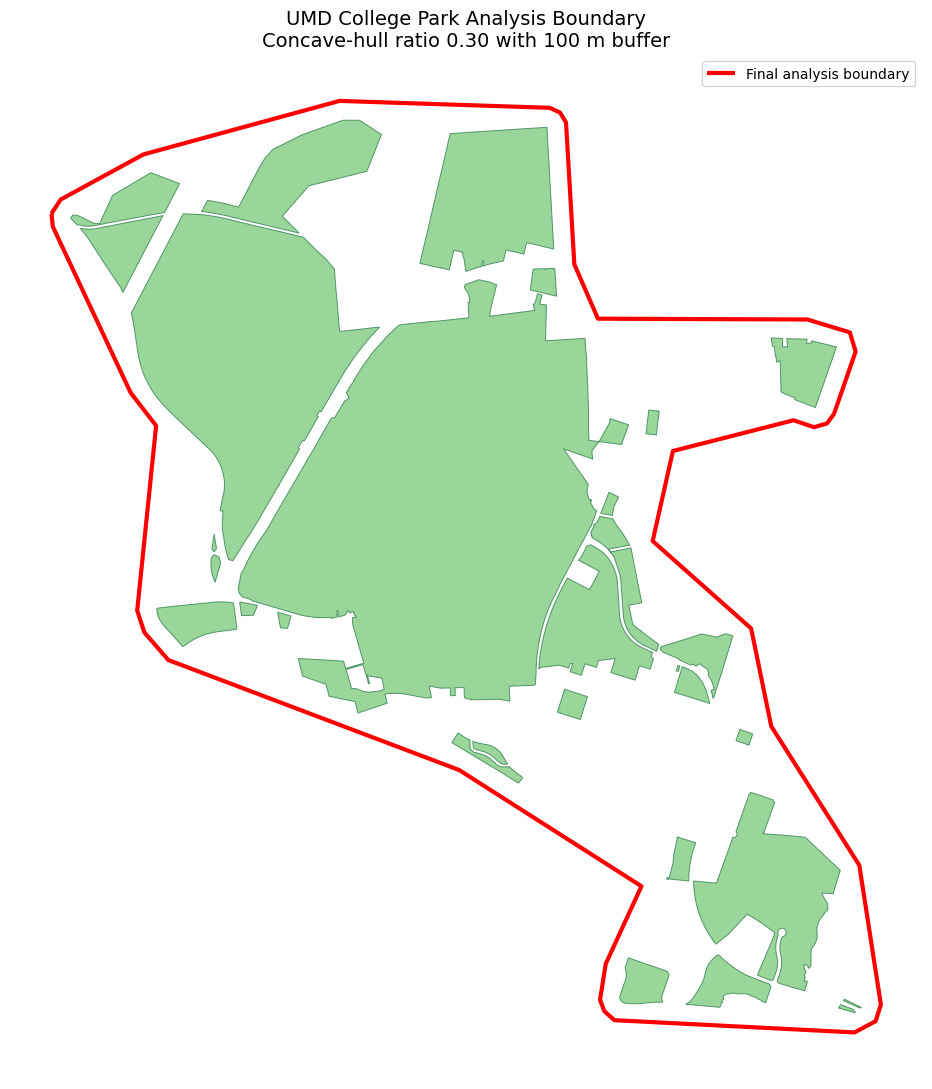

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 11))

# Official parcels
umd_projected.plot(
    ax=ax,
    color="#79c879",
    edgecolor="#287a48",
    linewidth=0.7,
    alpha=0.75,
    label="Official UMD parcels"
)

# Final analysis boundary
umd_aoi.boundary.plot(
    ax=ax,
    color="red",
    linewidth=3,
    label="Final analysis boundary"
)

ax.set_title(
    "UMD College Park Analysis Boundary\n"
    "Concave-hull ratio 0.30 with 100 m buffer",
    fontsize=14
)

ax.set_axis_off()
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
import folium

umd_web = umd.to_crs("EPSG:4326")
umd_aoi_web = umd_aoi.to_crs("EPSG:4326")

center = umd_aoi_web.geometry.iloc[0].centroid

m = folium.Map(
    location=[center.y, center.x],
    zoom_start=14,
    tiles="CartoDB positron"
)

# Official parcels
folium.GeoJson(
    umd_web.to_json(),
    name="Official UMD parcels",
    style_function=lambda feature: {
        "fillColor": "#66c2a5",
        "color": "#238b45",
        "weight": 1,
        "fillOpacity": 0.60
    }
).add_to(m)

# Final surrounding boundary
folium.GeoJson(
    umd_aoi_web.to_json(),
    name="Final analysis boundary",
    style_function=lambda feature: {
        "fillColor": "#ff0000",
        "color": "#ff0000",
        "weight": 4,
        "fillOpacity": 0.05
    }
).add_to(m)

folium.LayerControl().add_to(m)

m

In [13]:
from google.colab import files

output_file = "umd_analysis_boundary_ratio_0.30.geojson"

# Export in standard GeoJSON coordinates
umd_aoi_web.to_file(
    output_file,
    driver="GeoJSON"
)

print(f"Created: {output_file}")

files.download(output_file)

Created: umd_analysis_boundary_ratio_0.30.geojson


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>